In [ ]:
import pandas as pd
import ast
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, GRU, LSTM, Bidirectional, Dense, TimeDistributed
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import Accuracy
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping
from itertools import chain
import seaborn as sns
from collections import Counter

In [ ]:
train_file_link="https://drive.google.com/file/d/1NY_EEYluQpBSgbrnF7hC4GQmPIKw2_na/view?usp=drive_link"
train_id = train_file_link.split("/")[-2]
new_train_link = f'https://drive.google.com/uc?id={train_id}'
train_df = pd.read_csv(new_train_link)

test_file_link="https://drive.google.com/file/d/17bxSFF_bhSXeE1NcQXfXmW503nmKoDdW/view?usp=drive_link"
test_id = test_file_link.split("/")[-2]
new_test_link = f'https://drive.google.com/uc?id={test_id}'
test_df = pd.read_csv(new_test_link)

In [ ]:
print(train_df.head())
print("\nData types:\n", train_df.dtypes)
print(train_df.isnull().sum())

   Sentence #                                           Sentence  \
0           1  AU officials reported fresh fighting Sunday , ...   
1           2  Also Saturday , in an unrelated development , ...   
2           3  They replied , " We would willingly have helpe...   
3           4          He said he has ordered an investigation .   
4           5  World famous Russian cellist and conductor , M...   

                                                 POS  
0  ['NNP', 'NNS', 'VBD', 'JJ', 'NN', 'NNP', ',', ...  
1  ['RB', 'NNP', ',', 'IN', 'DT', 'JJ', 'NN', ','...  
2  ['PRP', 'VBD', ',', '``', 'PRP', 'MD', 'RB', '...  
3  ['PRP', 'VBD', 'PRP', 'VBZ', 'VBN', 'DT', 'NN'...  
4  ['NNP', 'JJ', 'JJ', 'NN', 'CC', 'NN', ',', 'NN...  

Data types:
 Sentence #     int64
Sentence      object
POS           object
dtype: object
Sentence #    0
Sentence      0
POS           0
dtype: int64


In [ ]:
print("\nTotal entries in each column:\n", train_df.count())
# all_tags = []


Total entries in each column:
 Sentence #    19183
Sentence      19183
POS           19183
dtype: int64


In [ ]:
train_df['POS'] = train_df['POS'].apply(ast.literal_eval)
test_df['POS'] = test_df['POS'].apply(ast.literal_eval)

In [ ]:
train_df['tokens'] = train_df['Sentence'].apply(str.split)

In [ ]:
all_pos_tags = list(chain.from_iterable(train_df['POS']))
print("Total number of POS tags:", len(all_pos_tags))

Total number of POS tags: 418968


In [ ]:
unique_pos_tags = set(all_pos_tags)
print("Unique POS tags:", unique_pos_tags)
print("Number of unique POS tags:", len(unique_pos_tags))

Unique POS tags: {'JJR', 'PDT', 'NNPS', 'VB', 'UH', ';', 'LRB', '$', 'WP', 'CC', 'RRB', 'VBD', 'WDT', '.', 'RBR', 'RP', 'TO', 'JJ', 'WRB', 'DT', ',', 'EX', 'VBN', 'PRP', 'VBP', 'VBG', 'RBS', 'NNS', 'NN', 'POS', ':', 'VBZ', 'CD', 'NNP', 'PRP$', 'MD', 'JJS', 'IN', 'RB', 'WP$', '``'}
Number of unique POS tags: 41


In [ ]:
train_df['sentence_length'] = train_df['Sentence'].apply(lambda x: len(x.split())) # Calculating word count for each sentence
sentence_lengths = train_df.groupby('Sentence')['sentence_length'].sum()

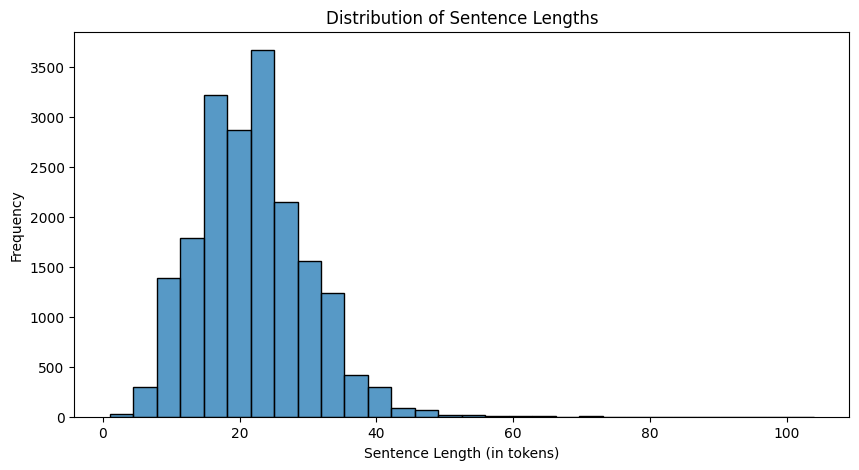

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(sentence_lengths, bins=30, kde=False)
plt.title('Distribution of Sentence Lengths')
plt.xlabel('Sentence Length (in tokens)')
plt.ylabel('Frequency')
plt.show()

In [ ]:
# Most common words
all_tokens = list(chain.from_iterable(train_df['tokens']))
word_counts = Counter(all_tokens)

# Show the top 10 most common words
print("Most common words:")
print(word_counts.most_common(20))

Most common words:
[('the', 21060), ('.', 19102), (',', 13096), ('in', 10546), ('of', 10452), ('to', 9336), ('a', 8269), ('and', 7953), ('The', 4518), ("'s", 4382), ('for', 3435), ('has', 2916), ('on', 2679), ('is', 2657), ('that', 2494), ('with', 2197), ('have', 2191), ('said', 2109), ('was', 1962), ('says', 1856)]


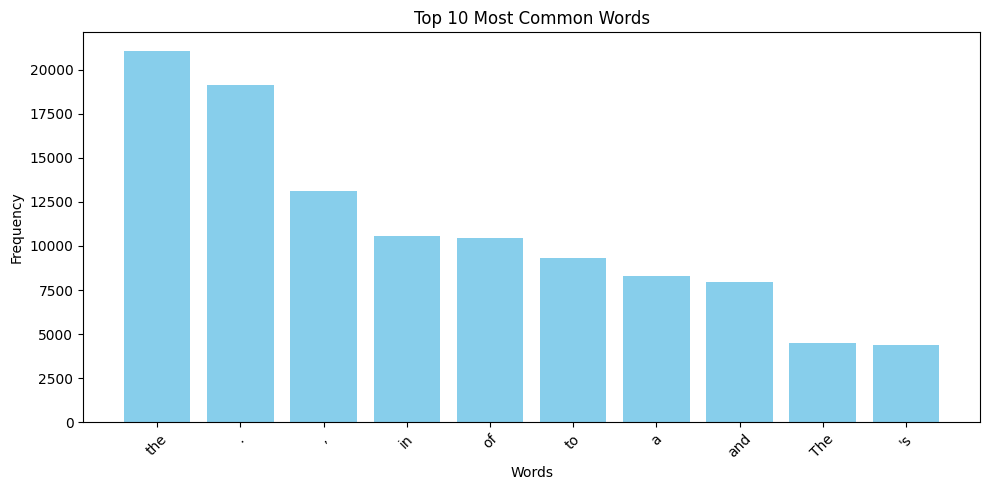

In [ ]:
common_words = word_counts.most_common(10)
words, word_freqs = zip(*common_words)

plt.figure(figsize=(10, 5))
plt.bar(words, word_freqs, color='skyblue')
plt.title('Top 10 Most Common Words')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
all_tags = list(chain.from_iterable(train_df['POS']))
tag_counts = Counter(all_tags)

# Show the top 10 most common POS tags
print("Most common POS tags:")
print(tag_counts.most_common(20))

Most common POS tags:
[('NN', 58417), ('NNP', 52470), ('IN', 48224), ('DT', 39573), ('JJ', 31267), ('NNS', 30299), ('.', 19129), ('VBD', 15672), (',', 13099), ('VBN', 13002), ('VBZ', 9957), ('VB', 9735), ('CD', 9711), ('CC', 9469), ('TO', 9266), ('RB', 8101), ('VBG', 7714), ('VBP', 6548), ('PRP', 5311), ('POS', 4529)]


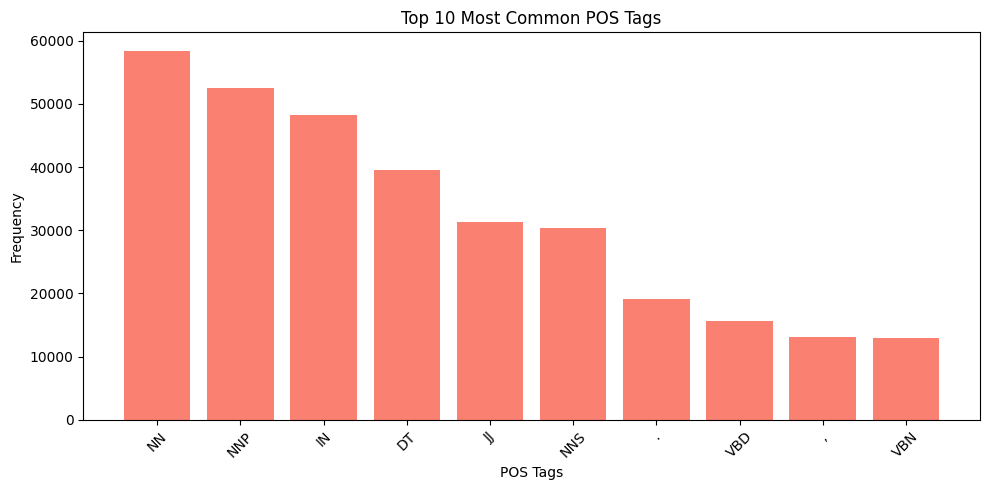

In [ ]:
# Most common POS tags
common_tags = tag_counts.most_common(10)
tags, tag_freqs = zip(*common_tags)

plt.figure(figsize=(10, 5))
plt.bar(tags, tag_freqs, color='salmon')
plt.title('Top 10 Most Common POS Tags')
plt.xlabel('POS Tags')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
mismatch_rows = [(i, len(w), len(t)) for i, (w, t) in enumerate(zip(train_df['tokens'], train_df['POS'])) if len(w) != len(t)]
if mismatch_rows:
    print(f"Found {len(mismatch_rows)} mismatched rows (token count ≠ tag count)")
    for i, token_len, tag_len in mismatch_rows[:5]:  # show first 5
        print(f"Row {i} — Tokens: {token_len}, Tags: {tag_len}")
    train_df = train_df[[len(w) == len(t) for w, t in zip(train_df['tokens'], train_df['POS'])]]

Found 3 mismatched rows (token count ≠ tag count)
Row 8626 — Tokens: 52, Tags: 54
Row 10197 — Tokens: 37, Tags: 38
Row 12343 — Tokens: 28, Tags: 29


In [ ]:
train_df.shape

(19180, 5)

In [ ]:
word_tokenizer = Tokenizer(lower=False, oov_token='<OOV>')
word_tokenizer.fit_on_texts(train_df['tokens'])

tag_encoder = LabelEncoder()
tag_encoder.fit([tag for tags in train_df['POS'] for tag in tags])

X_train_seq = word_tokenizer.texts_to_sequences(train_df['tokens'])
X_test_seq = word_tokenizer.texts_to_sequences(test_df['Sentence'].apply(str.split))

y_train_seq = [[tag_encoder.transform([tag])[0] for tag in tags] for tags in train_df['POS']]
y_test_seq = [[tag_encoder.transform([tag])[0] for tag in tags] for tags in test_df['POS']]


In [ ]:
MAX_LEN = max([len(seq) for seq in X_train_seq])

X_train_padded = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post')
X_test_padded = pad_sequences(X_test_seq, maxlen=MAX_LEN, padding='post')

y_train_padded = pad_sequences(y_train_seq, maxlen=MAX_LEN, padding='post')
y_test_padded = pad_sequences(y_test_seq, maxlen=MAX_LEN, padding='post')

In [ ]:
num_tags = len(tag_encoder.classes_)

y_train_cat = to_categorical(y_train_padded, num_classes=num_tags)
y_test_cat = to_categorical(y_test_padded, num_classes=num_tags)

In [ ]:
from sklearn.model_selection import train_test_split

X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train_padded, y_train_cat, test_size=0.1, random_state=42
)

In [ ]:
#RNN

vocab_size = len(word_tokenizer.word_index) + 1
embedding_dim = 128
rnn_units = 64
batch_size = 128
epochs = 15

rnn_model = Sequential()
rnn_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_LEN))
rnn_model.add(SimpleRNN(units=rnn_units, return_sequences=True))
rnn_model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

rnn_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_rnn = rnn_model.fit(X_train_final, y_train_final, validation_data=(X_val, y_val), batch_size=batch_size, epochs=epochs, verbose=1, callbacks=[early_stop])

rnn_model.summary()

y_pred = rnn_model.predict(X_test_padded)
y_pred_labels = np.argmax(y_pred, axis=-1)
y_true_labels = np.argmax(y_test_cat, axis=-1)

y_pred_flat = []
y_true_flat = []

for i in range(len(y_true_labels)):
    for j in range(len(y_true_labels[i])):
        if y_true_labels[i][j] != 0:
            y_true_flat.append(y_true_labels[i][j])
            y_pred_flat.append(y_pred_labels[i][j])

labels = list(range(len(tag_encoder.classes_)))
print(classification_report(y_true_flat, y_pred_flat, labels=labels, target_names=tag_encoder.classes_))

f1 = f1_score(y_true_flat, y_pred_flat, average='macro')
print("Macro F1-score:", f1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 37s 208ms/step - accuracy: 0.7940 - loss: 0.9879 - val_accuracy: 0.9392 - val_loss: 0.2858
Epoch 2/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 31s 229ms/step - accuracy: 0.9516 - loss: 0.2353 - val_accuracy: 0.9767 - val_loss: 0.1201
Epoch 3/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 41s 229ms/step - accuracy: 0.9820 - loss: 0.0989 - val_accuracy: 0.9863 - val_loss: 0.0652
Epoch 4/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 36s 193ms/step - accuracy: 0.9906 - loss: 0.0512 - val_accuracy: 0.9895 - val_loss: 0.0454
Epoch 5/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 43s 209ms/step - accuracy: 0.9937 - loss: 0.0319 - val_accuracy: 0.9908 - val_loss: 0.0368
Epoch 6/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 42s 217ms/step - accuracy: 0.9950 - loss: 0.0230 - val_accuracy: 0.9912 - val_loss: 0.0325
Epoch 7/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 41s 215ms/step - accuracy: 0.9958 - loss: 0.0179 - val_accuracy: 0.9917 - val_loss: 0.0300
Epoch 8/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 41s 214ms/step - accuracy: 0.9963 - loss: 0

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 104, 128)       │     2,931,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 104, 64)        │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 104, 41)        │         2,665 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,839,805 (33.72 MB)

 Trainable params: 2,946,601 (11.24 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,893,204 (22.48 MB)

150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step
              precision    recall  f1-score   support

           $       0.00      0.00      0.00         0
           ,       1.00      1.00      1.00      3314
           .       1.00      1.00      1.00      4789
           :       0.57      0.62      0.59        73
           ;       1.00      1.00      1.00        22
          CC       1.00      1.00      1.00      2474
          CD       0.99      0.96      0.98      2522
          DT       1.00      1.00      1.00      9797
          EX       0.95      0.97      0.96        75
          IN       0.98      0.99      0.99     12190
          JJ       0.90      0.91      0.90      7807
         JJR       0.87      0.96      0.91       291
         JJS       0.96      0.92      0.94       309
         LRB       1.00      1.00      1.00        67
          MD       1.00      1.00      1.00       734
          NN       0.96      0.95      0.95     14705
         NNP       0.94      0.97      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

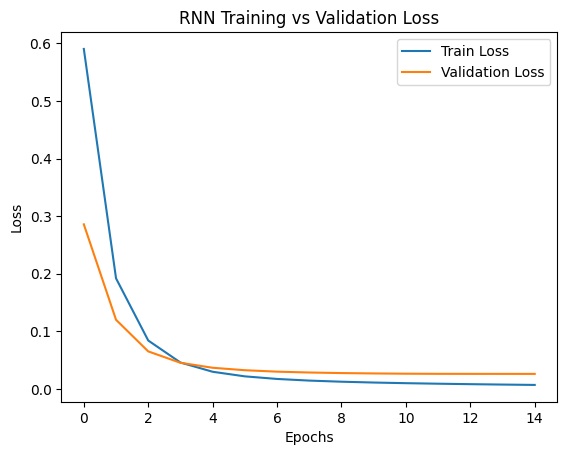

In [ ]:
plt.plot(history_rnn.history['loss'], label='Train Loss')
plt.plot(history_rnn.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.title('RNN Training vs Validation Loss')
plt.show()

In [ ]:
# GRU

vocab_size = len(word_tokenizer.word_index) + 1
embedding_dim = 128
rnn_units = 64
batch_size = 128
epochs = 15

gru_model = Sequential()
gru_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_LEN))
gru_model.add(GRU(units=rnn_units, return_sequences=True))
gru_model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

gru_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=1, restore_best_weights=True)

history_gru = gru_model.fit(X_train_final, y_train_final, validation_data=(X_val, y_val), batch_size=batch_size, epochs=epochs, verbose=1, callbacks=[early_stop])

gru_model.summary()

# Predictions and evaluation
y_pred = gru_model.predict(X_test_padded)
y_pred_labels = np.argmax(y_pred, axis=-1)
y_true_labels = np.argmax(y_test_cat, axis=-1)

y_pred_flat = []
y_true_flat = []

for i in range(len(y_true_labels)):
    for j in range(len(y_true_labels[i])):
        if y_true_labels[i][j] != 0:  # Avoid padding
            y_true_flat.append(y_true_labels[i][j])
            y_pred_flat.append(y_pred_labels[i][j])

labels = list(range(len(tag_encoder.classes_)))
print(classification_report(y_true_flat, y_pred_flat, labels=labels, target_names=tag_encoder.classes_))

f1 = f1_score(y_true_flat, y_pred_flat, average='macro')
print("Macro F1-score:", f1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 62s 391ms/step - accuracy: 0.8482 - loss: 0.9287 - val_accuracy: 0.9565 - val_loss: 0.2102
Epoch 2/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 88s 439ms/step - accuracy: 0.9674 - loss: 0.1614 - val_accuracy: 0.9847 - val_loss: 0.0745
Epoch 3/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 83s 445ms/step - accuracy: 0.9888 - loss: 0.0595 - val_accuracy: 0.9894 - val_loss: 0.0449
Epoch 4/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 82s 445ms/step - accuracy: 0.9931 - loss: 0.0333 - val_accuracy: 0.9909 - val_loss: 0.0350
Epoch 5/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 80s 434ms/step - accuracy: 0.9945 - loss: 0.0231 - val_accuracy: 0.9914 - val_loss: 0.0304
Epoch 6/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 83s 444ms/step - accuracy: 0.9952 - loss: 0.0180 - val_accuracy: 0.9918 - val_loss: 0.0280
Epoch 7/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 82s 442ms/step - accuracy: 0.9959 - loss: 0.0147 - val_accuracy: 0.9920 - val_loss: 0.0267
Epoch 8/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 81s 432ms/step - accuracy: 0.9962 - loss: 0

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_7 (Embedding)         │ (None, 104, 128)       │     2,931,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 104, 64)        │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_7              │ (None, 104, 41)        │         2,665 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,914,493 (34.01 MB)

 Trainable params: 2,971,497 (11.34 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,942,996 (22.67 MB)

150/150 ━━━━━━━━━━━━━━━━━━━━ 6s 34ms/step
              precision    recall  f1-score   support

           $       0.00      0.00      0.00         0
           ,       1.00      1.00      1.00      3314
           .       1.00      1.00      1.00      4789
           :       0.56      0.55      0.55        73
           ;       1.00      1.00      1.00        22
          CC       1.00      1.00      1.00      2474
          CD       1.00      0.95      0.97      2522
          DT       1.00      1.00      1.00      9797
          EX       0.93      0.99      0.95        75
          IN       0.98      0.99      0.99     12190
          JJ       0.90      0.91      0.91      7807
         JJR       0.85      0.95      0.90       291
         JJS       0.96      0.94      0.95       309
         LRB       1.00      0.99      0.99        67
          MD       1.00      1.00      1.00       734
          NN       0.94      0.96      0.95     14705
         NNP       0.94      0.97      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

In [ ]:
#LSTM

vocab_size = len(word_tokenizer.word_index) + 1
embedding_dim = 128
rnn_units = 64
batch_size = 128
epochs = 15

lstm_model = Sequential()
lstm_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_LEN))
lstm_model.add(LSTM(units=rnn_units, return_sequences=True))
lstm_model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

lstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_lstm = lstm_model.fit(X_train_final, y_train_final, validation_data=(X_val, y_val), batch_size=batch_size, epochs=epochs, verbose=1, callbacks=[early_stop])

lstm_model.summary()

y_pred = lstm_model.predict(X_test_padded)
y_pred_labels = np.argmax(y_pred, axis=-1)
y_true_labels = np.argmax(y_test_cat, axis=-1)

y_pred_flat = []
y_true_flat = []

for i in range(len(y_true_labels)):
    for j in range(len(y_true_labels[i])):
        if y_true_labels[i][j] != 0:  # Ignore padding
            y_true_flat.append(y_true_labels[i][j])
            y_pred_flat.append(y_pred_labels[i][j])

labels = list(range(len(tag_encoder.classes_)))
print(classification_report(y_true_flat, y_pred_flat, labels=labels, target_names=tag_encoder.classes_))

f1 = f1_score(y_true_flat, y_pred_flat, average='macro')
print("Macro F1-score:", f1)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 69s 444ms/step - accuracy: 0.8027 - loss: 1.0583 - val_accuracy: 0.9103 - val_loss: 0.3771
Epoch 2/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 71s 361ms/step - accuracy: 0.9307 - loss: 0.3069 - val_accuracy: 0.9731 - val_loss: 0.1428
Epoch 3/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 85s 384ms/step - accuracy: 0.9792 - loss: 0.1157 - val_accuracy: 0.9858 - val_loss: 0.0719
Epoch 4/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 83s 392ms/step - accuracy: 0.9900 - loss: 0.0575 - val_accuracy: 0.9892 - val_loss: 0.0492
Epoch 5/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 81s 382ms/step - accuracy: 0.9930 - loss: 0.0368 - val_accuracy: 0.9904 - val_loss: 0.0395
Epoch 6/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 84s 401ms/step - accuracy: 0.9944 - loss: 0.0266 - val_accuracy: 0.9908 - val_loss: 0.0348
Epoch 7/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 79s 382ms/step - accuracy: 0.9952 - loss: 0.0213 - val_accuracy: 0.9913 - val_loss: 0.0318
Epoch 8/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 81s 377ms/step - accuracy: 0.9957 - loss: 0

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_8 (Embedding)         │ (None, 104, 128)       │     2,931,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 104, 64)        │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_8              │ (None, 104, 41)        │         2,665 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,950,973 (34.15 MB)

 Trainable params: 2,983,657 (11.38 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,967,316 (22.76 MB)

150/150 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step
              precision    recall  f1-score   support

           $       0.00      0.00      0.00         0
           ,       1.00      1.00      1.00      3314
           .       1.00      1.00      1.00      4789
           :       0.63      0.85      0.73        73
           ;       1.00      1.00      1.00        22
          CC       1.00      1.00      1.00      2474
          CD       1.00      0.95      0.97      2522
          DT       1.00      1.00      1.00      9797
          EX       0.89      0.96      0.92        75
          IN       0.99      0.99      0.99     12190
          JJ       0.90      0.92      0.91      7807
         JJR       0.86      0.96      0.91       291
         JJS       0.92      0.95      0.94       309
         LRB       1.00      1.00      1.00        67
          MD       1.00      1.00      1.00       734
          NN       0.95      0.95      0.95     14705
         NNP       0.95      0.96      

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

In [ ]:
#BiLSTM

vocab_size = len(word_tokenizer.word_index) + 1
embedding_dim = 128
rnn_units = 64
batch_size = 128
epochs = 15

bilstm_model = Sequential()
bilstm_model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, input_length=MAX_LEN))
bilstm_model.add(Bidirectional(LSTM(units=rnn_units, return_sequences=True)))
bilstm_model.add(TimeDistributed(Dense(num_tags, activation='softmax')))

bilstm_model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history_bilstm = bilstm_model.fit(X_train_final, y_train_final, validation_data=(X_val, y_val), batch_size=batch_size, epochs=epochs, verbose=1, callbacks=[early_stop])

bilstm_model.summary()

y_pred = bilstm_model.predict(X_test_padded)
y_pred_labels = np.argmax(y_pred, axis=-1)
y_true_labels = np.argmax(y_test_cat, axis=-1)

y_pred_flat = []
y_true_flat = []

for i in range(len(y_true_labels)):
    for j in range(len(y_true_labels[i])):
        if y_true_labels[i][j] != 0:
            y_true_flat.append(y_true_labels[i][j])
            y_pred_flat.append(y_pred_labels[i][j])

labels = list(range(len(tag_encoder.classes_)))
print(classification_report(y_true_flat, y_pred_flat, labels=labels, target_names=tag_encoder.classes_))

f1 = f1_score(y_true_flat, y_pred_flat, average='macro')
print("Macro F1-score:", f1)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 126s 849ms/step - accuracy: 0.7945 - loss: 0.9560 - val_accuracy: 0.9307 - val_loss: 0.2873
Epoch 2/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 136s 809ms/step - accuracy: 0.9490 - loss: 0.2203 - val_accuracy: 0.9821 - val_loss: 0.0848
Epoch 3/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 143s 814ms/step - accuracy: 0.9871 - loss: 0.0667 - val_accuracy: 0.9898 - val_loss: 0.0439
Epoch 4/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 144s 833ms/step - accuracy: 0.9931 - loss: 0.0331 - val_accuracy: 0.9920 - val_loss: 0.0315
Epoch 5/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 140s 814ms/step - accuracy: 0.9954 - loss: 0.0208 - val_accuracy: 0.9930 - val_loss: 0.0263
Epoch 6/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 142s 820ms/step - accuracy: 0.9965 - loss: 0.0151 - val_accuracy: 0.9935 - val_loss: 0.0235
Epoch 7/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 140s 804ms/step - accuracy: 0.9972 - loss: 0.0116 - val_accuracy: 0.9938 - val_loss: 0.0219
Epoch 8/15
135/135 ━━━━━━━━━━━━━━━━━━━━ 108s 803ms/step - accuracy: 0.9977 -

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_9 (Embedding)         │ (None, 104, 128)       │     2,931,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 104, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_9              │ (None, 104, 41)        │         5,289 │
│ (TimeDistributed)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,107,069 (34.74 MB)

...

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 6,071,380 (23.16 MB)

150/150 ━━━━━━━━━━━━━━━━━━━━ 8s 42ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/me

              precision    recall  f1-score   support

           $       0.00      0.00      0.00         0
           ,       1.00      1.00      1.00      3314
           .       1.00      1.00      1.00      4789
           :       0.81      0.90      0.86        73
           ;       1.00      1.00      1.00        22
          CC       1.00      1.00      1.00      2474
          CD       0.99      0.96      0.97      2522
          DT       1.00      1.00      1.00      9797
          EX       0.94      0.97      0.95        75
          IN       0.99      0.99      0.99     12190
          JJ       0.93      0.94      0.94      7807
         JJR       0.88      0.95      0.91       291
         JJS       0.97      0.94      0.96       309
         LRB       1.00      0.97      0.98        67
          MD       1.00      1.00      1.00       734
          NN       0.96      0.97      0.97     14705
         NNP       0.96      0.97      0.97     13148
        NNPS       0.88    